<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/NLP/NLP05/HuggingFacePrj_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 1. NSMC 데이터 분석 및 Huggingface dataset 구성
데이터셋은 깃허브에서 다운받거나, Huggingface datasets에서 가져올 수 있습니다. 앞에서 배운 방법들을 활용해봅시다!
#STEP 2. klue/bert-base model 및 tokenizer 불러오기
#STEP 3. 위에서 불러온 tokenizer으로 데이터셋을 전처리하고, model 학습 진행해 보기
#STEP 4. Fine-tuning을 통하여 모델 성능(accuarcy) 향상시키기
데이터 전처리, TrainingArguments 등을 조정하여 모델의 정확도를 90% 이상으로 끌어올려봅시다.
#STEP 5. Bucketing을 적용하여 학습시키고, STEP 4의 결과와의 비교
아래 링크를 바탕으로 bucketing과 dynamic padding이 무엇인지 알아보고, 이들을 적용하여 model을 학습시킵니다.

#전체 그림
1.NSMC 데이터(document, label)

2.Hugging Face Dataset

3.tokenizer(input_ids, attention_mask, label)

4.klue/bert-base

5.Trainer 학습

6.accuracy 평가

7.bucketing + dynamic padding 적용 후 비교

In [1]:
#import tensorflow
import numpy
import transformers
import datasets

print(tensorflow.__version__)
print(numpy.__version__)
print(transformers.__version__)
print(datasets.__version__)


from google.colab import drive
drive.mount('/content/drive')

import json

home_path = "/content/drive/MyDrive/Colab Notebooks/"

NameError: name 'tensorflow' is not defined

#STEP 0. 설치

In [3]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


# STEP 1. NSMC 데이터 불러오기

In [5]:
from datasets import load_dataset

data_files = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
}

dataset = load_dataset(
    "csv",
    data_files=data_files,
    delimiter="\t"
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

In [ ]:
from datasets import load_dataset

data_files = {
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
}

dataset = load_dataset(
    "csv",
    data_files=data_files,
    delimiter="\t"
)

dataset

# STEP 1-1. 데이터 확인

In [6]:
dataset["train"][0]

{'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}

In [7]:
dataset["train"].features

{'id': Value('int64'), 'document': Value('string'), 'label': Value('int64')}

In [8]:
print(dataset["train"].column_names)
print(dataset["test"].column_names)

['id', 'document', 'label']
['id', 'document', 'label']


# STEP 1-2. 결측치 제거

In [9]:
dataset = dataset.filter(lambda x: x["document"] is not None)

Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [10]:
dataset["train"][0]

{'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}

#STEP 1-3. 빠른 실험용 샘플링

처음부터 전체 데이터로 돌리면 오래 걸릴 수 있으니 먼저 작은 데이터로 확인한다.

In [11]:
#small_train = dataset["train"].shuffle(seed=42).select(range(10000))
#small_val = dataset["test"].shuffle(seed=42).select(range(2000))

In [12]:
small_train = dataset["train"]
small_val = dataset["test"]

#STEP 2. klue/bert-base 모델과 토크나이저 불러오기

klue/bert-base는 한국어 KLUE 벤치마크 개발 맥락에서 공개된 한국어 BERT base 모델이다.

In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "klue/bert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
#여기서 classifier.weight, classifier.bias가 새로 초기화됐다는 경고가 나올 수 있다.
#정상이다. 기존 BERT 위에 NSMC 긍정/부정 분류용 머리를 새로 붙이는 과정이다.

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

#STEP 3. 토크나이징 전처리
고정 패딩 방식

모든 문장을 max_length=128 길이로 맞춘다.

In [14]:
def tokenize_function(batch):
    return tokenizer(
        batch["document"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [15]:
tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_val = small_val.map(tokenize_function, batched=True)

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

In [16]:
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

#STEP 3-1. 평가 함수 만들기

In [17]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

#STEP 3-2. 기본 학습

In [18]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./nsmc-klue-bert-basic",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none"
)
#구버전 transformers에서 eval_strategy 오류가 나면 이것으로 바꿔라.

In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

#STEP 4. Fine-tuning으로 정확도 올리기

In [20]:
train_dataset = dataset["train"]
val_dataset = dataset["test"]

In [21]:
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["id", "document"])
tokenized_val = tokenized_val.remove_columns(["id", "document"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [23]:
training_args = TrainingArguments(
    output_dir="./nsmc-klue-bert-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=500,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=True,
    report_to="none"
)

#GPU에서 fp16=True 오류가 나면 fp16=False로 바꿔라.

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [24]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.247817,0.239782,0.900574
2,0.180316,0.250847,0.906914
3,0.122514,0.293201,0.907314


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=14064, training_loss=0.20425529874632384, metrics={'train_runtime': 2907.8325, 'train_samples_per_second': 154.749, 'train_steps_per_second': 4.837, 'total_flos': 2.95990070615424e+16, 'train_loss': 0.20425529874632384, 'epoch': 3.0})

In [26]:
finetune_result = trainer.evaluate()
finetune_result

{'eval_loss': 0.2932007610797882,
 'eval_accuracy': 0.907314438866332,
 'eval_runtime': 84.5141,
 'eval_samples_per_second': 591.582,
 'eval_steps_per_second': 18.494,
 'epoch': 3.0}

STEP 5. Bucketing + Dynamic Padding 적용
개념 그림

기본 padding:

문장 A 길이 10  →  128까지 padding
문장 B 길이 20  →  128까지 padding
문장 C 길이 70  →  128까지 padding

낭비가 많다.

Dynamic padding:

한 배치 안에서 가장 긴 문장 길이까지만 padding

Bucketing:

길이 비슷한 문장끼리 묶음
짧은 문장끼리 batch
긴 문장끼리 batch

효과:

padding 감소
↓
연산량 감소
↓
학습 시간 단축

STEP 5-1. Dynamic padding용 전처리

이번에는 padding="max_length"를 제거한다.

In [27]:
def tokenize_no_padding(batch):
    return tokenizer(
        batch["document"],
        truncation=True,
        max_length=128
    )

In [28]:
bucket_train = dataset["train"].map(tokenize_no_padding, batched=True)
bucket_val = dataset["test"].map(tokenize_no_padding, batched=True)

bucket_train = bucket_train.remove_columns(["id", "document"])
bucket_val = bucket_val.remove_columns(["id", "document"])

bucket_train.set_format("torch")
bucket_val.set_format("torch")

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

STEP 5-2. DataCollatorWithPadding 사용

In [29]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)
#DataCollatorWithPadding은 배치가 만들어질 때 그 배치 안에서 필요한 만큼만 padding을 붙인다.

STEP 5-3. Bucketing 학습 설정

In [30]:
group_by_length=True

In [31]:
bucket_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [32]:
bucket_training_args = TrainingArguments(
    output_dir="./nsmc-klue-bert-bucketing",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=500,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=True,
    group_by_length=True,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [34]:
bucket_trainer = Trainer(
    model=bucket_model,
    args=bucket_training_args,
    train_dataset=bucket_train,
    eval_dataset=bucket_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [35]:
bucket_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.249367,0.258237,0.900194
2,0.183625,0.250620,0.907274
3,0.118835,0.295842,0.907494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=14064, training_loss=0.2043995281535204, metrics={'train_runtime': 1399.0425, 'train_samples_per_second': 321.638, 'train_steps_per_second': 10.053, 'total_flos': 5424989725488420.0, 'train_loss': 0.2043995281535204, 'epoch': 3.0})

In [36]:
bucket_result = bucket_trainer.evaluate()
bucket_result

{'eval_loss': 0.29584336280822754,
 'eval_accuracy': 0.9075144508670521,
 'eval_runtime': 32.6762,
 'eval_samples_per_second': 1530.072,
 'eval_steps_per_second': 47.833,
 'epoch': 3.0}

STEP 6. 결과 비교표 만들기

In [39]:
import pandas as pd

compare_df = pd.DataFrame([
    {
        "method": "fine_tuning_fixed_padding",
        "accuracy": finetune_result.get("eval_accuracy"),
        "loss": finetune_result.get("eval_loss"),
    },
    {
        "method": "bucketing_dynamic_padding",
        "accuracy": bucket_result.get("eval_accuracy"),
        "loss": bucket_result.get("eval_loss"),
    },
])

compare_df

,method,accuracy,loss
0,fine_tuning_fixed_padding,0.907314,0.293201
1,bucketing_dynamic_padding,0.907514,0.295843


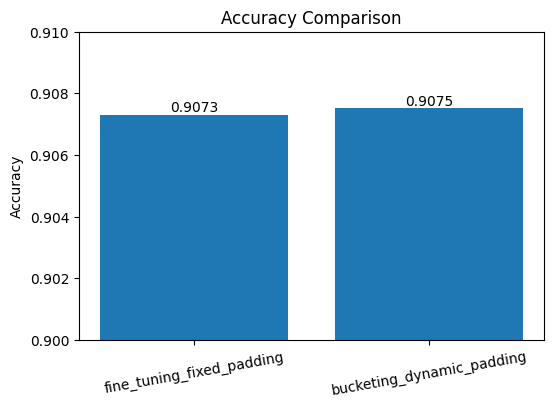

In [40]:
import matplotlib.pyplot as plt

methods = compare_df["method"]
accuracy = compare_df["accuracy"]
loss = compare_df["loss"]

# Accuracy 그래프
plt.figure(figsize=(6,4))
plt.bar(methods, accuracy)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0.90, 0.91)
plt.xticks(rotation=10)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.0001, f"{v:.4f}", ha='center')

plt.show()

최종 해석 기준
accuracy 측면:
fine-tuning 설정이 좋아지면 정확도 상승 가능

훈련 시간 측면:
bucketing + dynamic padding은 padding 토큰을 줄여서 보통 더 효율적

성능 측면:
bucketing 자체가 정확도를 직접 올리는 기술은 아님
하지만 batch 구성과 padding 효율이 좋아져 학습이 안정될 수 있음

정리하면:

정확도 향상 핵심:
learning_rate, epoch, batch_size, max_length, warmup_ratio

속도 향상 핵심:
DataCollatorWithPadding + group_by_length=True